# 2025 Kaggle Competition of AI Applied to Medicine at UC3M



Welcome to the **2025 Kaggle competition of AI applied to medicine at UC3M**. This project is set up as an **internal Kaggle competition** in which all students will participate. Our real-world challenge for this course will revolve around the **ISIC 2024** dataset, a large collection of skin images used for research in dermatology.


Welcome to our simple **ResNet50-based** starter notebook. Below we:
1. **Define** a function to load images from HDF5 files.
2. **Load** and display our training metadata (no preprocessing).
3. **Load** a pretrained **ResNet50** model (we won't fine-tune it).
4. **Evaluate** test samples (in a trivial way for demonstration).
5. **Generate** a simple `submission.csv` file with the required format.

> **Note**: This is a minimal example to help you set up your environment. It doesn’t include any real training or meaningful model inference. Feel free to modify it to perform actual classification (e.g., add custom layers, train on your dataset, etc.).

## ISIC 2024 Competition Overview

The **International Skin Imaging Collaboration (ISIC)** has launched this competition to advance automated skin cancer detection by:
- **Improving accuracy** in distinguishing malignant from benign lesions  
- **Enhancing efficiency** in clinical workflows  
- **Developing algorithms** that prioritize high-risk lesions  
- **Reducing mortality rates** by enabling earlier detection  

### Primary Task
You need to **classify skin lesions** as **benign** or **malignant**. For each lesion image (identified by `isic_id`), predict a **probability** in the range [0, 1] indicating the chance that the lesion is malignant.

### High-Level Data Summary
- The dataset is called **SLICE-3D**, containing **skin lesion images** (JPEG files) cropped from 3D Total Body Photography (TBP).  
- Each image has metadata in a corresponding `.csv` file, including:  
  - **Binary diagnostic label** (`target` = 0 or 1)  
  - **Patient data** (e.g., `age_approx`, `sex`, `anatom_site_general`)  
  - **Additional attributes** (image source, diagnosis type)

![](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F4972760%2F349a3ae1149d15dc5642063a2d742c88%2Fimage%20type_noexif_240425.jpg?generation=1714060307710359&alt=media)

This challenge dataset mimics **non-dermoscopic images** using standardized 15x15 mm “tiles” of lesions from a 3D TBP system. Thousands of patients from multiple continents are represented, creating a broad, diverse dataset.

### Task Description & Clinical Context
- **Why it matters**: Skin cancer can be deadly if not detected early. Many people lack access to dermatologic care, so accurate AI systems for image-based triage can improve outcomes.  
- **Key goal**: Develop a binary classifier that identifies malignant lesions from a set of smartphone-quality images.  
- **Impact**: This technology could help prioritize suspicious lesions (top K) for clinical review, especially in low-resource settings, potentially **saving lives** through earlier detection.

### Importance of 3D TBP
The **3D Total Body Photography (TBP)** approach captures the entire skin surface in macro resolution. Each lesion on the patient’s body is automatically cropped as a 15x15 mm image tile. These images more closely resemble photos taken by a regular smartphone camera, as opposed to specialized dermoscopy devices.

![](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F4972760%2F169b1f691322233e7b31aabaf6716ff3%2Fex-tiles.png?generation=1717700538524806&alt=media)

### Clinical Background
1. **Major skin cancer types**: Basal Cell Carcinoma (BCC), Squamous Cell Carcinoma (SCC), and Melanoma (most lethal).  
2. **Early detection** is crucial: Minor surgery can cure many skin cancers if caught in time.  
3. **Telemedicine implications**: With the rise in remote healthcare, patients often submit low-quality images captured at home. Robust AI models are needed to handle this variability.

### Summary
- You will build a model to **classify skin lesions** (benign vs. malignant) with probabilities.  
- The dataset includes **every lesion** from thousands of patients, reflecting real-world diversity.  
- **3D TBP** and the “ugly duckling sign” concept illustrate the importance of comparing each lesion against the patient’s total lesion landscape.  
- **Your work** can help improve early detection, prioritizing high-risk cases for clinical evaluation and potentially saving lives.


In [1]:
# =============================================================================
# ESSENTIAL IMPORTS & SETUP
# =============================================================================
import os
import h5py
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as T
from torchvision import models
from torchvision.transforms import InterpolationMode
import torch.optim as optim
from tqdm.auto import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data paths
TRAIN_METADATA_CSV = "data/train-metadata.csv"
TEST_METADATA_CSV = "data/test-metadata.csv"
TRAIN_HDF5 = "data/train-image.hdf5"
TEST_HDF5 = "data/test-image.hdf5"
BATCH_SIZE = 8

print("Essential imports and setup completed!")

Using device: cuda
Essential imports and setup completed!


In [2]:
# Metadata column descriptions and names

METADATA_COL2DESC = {
    "isic_id": "Unique identifier for each image case.",
    "target": "Binary class label (0 = benign, 1 = malignant).",
    "patient_id": "Unique identifier for each patient.",
    "age_approx": "Approximate age of the patient at time of imaging.",
    "sex": "Sex of the patient (male or female).",
    "anatom_site_general": "General location of the lesion on the patient's body.",
    "clin_size_long_diam_mm": "Maximum diameter of the lesion (mm).",
    "image_type": "Type of image captured, as defined in the ISIC Archive.",
    "tbp_tile_type": "Lighting modality of the 3D Total Body Photography (TBP) source image.",
    "tbp_lv_A": "Color channel A (green-red axis in LAB space) inside the lesion.",
    "tbp_lv_Aext": "Color channel A outside the lesion.",
    "tbp_lv_B": "Color channel B (blue-yellow axis in LAB space) inside the lesion.",
    "tbp_lv_Bext": "Color channel B outside the lesion.",
    "tbp_lv_C": "Chroma value inside the lesion.",
    "tbp_lv_Cext": "Chroma value outside the lesion.",
    "tbp_lv_H": "Hue value inside the lesion (LAB color space).",
    "tbp_lv_Hext": "Hue value outside the lesion.",
    "tbp_lv_L": "Luminance inside the lesion (LAB color space).",
    "tbp_lv_Lext": "Luminance outside the lesion.",
    "tbp_lv_areaMM2": "Area of the lesion in mm².",
    "tbp_lv_area_perim_ratio": "Ratio of the lesion's perimeter to its area (border jaggedness).",
    "tbp_lv_color_std_mean": "Mean color irregularity within the lesion.",
    "tbp_lv_deltaA": "Average contrast in color channel A between inside and outside.",
    "tbp_lv_deltaB": "Average contrast in color channel B between inside and outside.",
    "tbp_lv_deltaL": "Average contrast in luminance between inside and outside.",
    "tbp_lv_deltaLB": "Combined contrast between the lesion and surrounding skin.",
    "tbp_lv_deltaLBnorm": "Normalized contrast (LAB color space).",
    "tbp_lv_eccentricity": "Eccentricity of the lesion (how elongated it is).",
    "tbp_lv_location": "Detailed anatomical location (e.g., Upper Arm).",
    "tbp_lv_location_simple": "Simplified anatomical location (e.g., Arm).",
    "tbp_lv_minorAxisMM": "Smallest diameter of the lesion in mm.",
    "tbp_lv_nevi_confidence": "Confidence score (0-100) for the lesion being a nevus.",
    "tbp_lv_norm_border": "Normalized border irregularity (0-10 scale).",
    "tbp_lv_norm_color": "Normalized color variation (0-10 scale).",
    "tbp_lv_perimeterMM": "Perimeter of the lesion in mm.",
    "tbp_lv_radial_color_std_max": "Color asymmetry within the lesion, measured radially.",
    "tbp_lv_stdL": "Std. deviation of luminance inside the lesion.",
    "tbp_lv_stdLExt": "Std. deviation of luminance outside the lesion.",
    "tbp_lv_symm_2axis": "Asymmetry about a second axis of symmetry.",
    "tbp_lv_symm_2axis_angle": "Angle of that second axis of symmetry.",
    "tbp_lv_x": "X-coordinate in the 3D TBP model.",
    "tbp_lv_y": "Y-coordinate in the 3D TBP model.",
    "tbp_lv_z": "Z-coordinate in the 3D TBP model.",
    "attribution": "Image source or institution.",
    "copyright_license": "License information.",
    "lesion_id": "Unique ID for lesions of interest.",
    "iddx_full": "Full diagnosis classification.",
    "iddx_1": "First-level (broad) diagnosis.",
    "iddx_2": "Second-level diagnosis.",
    "iddx_3": "Third-level diagnosis.",
    "iddx_4": "Fourth-level diagnosis.",
    "iddx_5": "Fifth-level diagnosis.",
    "mel_mitotic_index": "Mitotic index of invasive malignant melanomas.",
    "mel_thick_mm": "Thickness of melanoma invasion in mm.",
    "tbp_lv_dnn_lesion_confidence": "Lesion confidence score (0-100) from a DNN classifier."
}

METADATA_COL2NAME = {
    "isic_id": "Unique Case Identifier",
    "target": "Binary Lesion Classification",
    "patient_id": "Unique Patient Identifier",
    "age_approx": "Approximate Age",
    "sex": "Sex",
    "anatom_site_general": "General Anatomical Location",
    "clin_size_long_diam_mm": "Clinical Size (Longest Diameter in mm)",
    "image_type": "Image Type",
    "tbp_tile_type": "TBP Tile Type",
    "tbp_lv_A": "Color Channel A (Inside)",
    "tbp_lv_Aext": "Color Channel A (Outside)",
    "tbp_lv_B": "Color Channel B (Inside)",
    "tbp_lv_Bext": "Color Channel B (Outside)",
    "tbp_lv_C": "Chroma (Inside)",
    "tbp_lv_Cext": "Chroma (Outside)",
    "tbp_lv_H": "Hue (Inside)",
    "tbp_lv_Hext": "Hue (Outside)",
    "tbp_lv_L": "Luminance (Inside)",
    "tbp_lv_Lext": "Luminance (Outside)",
    "tbp_lv_areaMM2": "Lesion Area (mm²)",
    "tbp_lv_area_perim_ratio": "Area-to-Perimeter Ratio",
    "tbp_lv_color_std_mean": "Mean Color Irregularity",
    "tbp_lv_deltaA": "Delta A",
    "tbp_lv_deltaB": "Delta B",
    "tbp_lv_deltaL": "Delta L",
    "tbp_lv_deltaLB": "Delta LB",
    "tbp_lv_deltaLBnorm": "Normalized Delta LB",
    "tbp_lv_eccentricity": "Eccentricity",
    "tbp_lv_location": "Detailed Location",
    "tbp_lv_location_simple": "Simplified Location",
    "tbp_lv_minorAxisMM": "Smallest Diameter (mm)",
    "tbp_lv_nevi_confidence": "Nevus Confidence Score",
    "tbp_lv_norm_border": "Normalized Border Irregularity",
    "tbp_lv_norm_color": "Normalized Color Variation",
    "tbp_lv_perimeterMM": "Lesion Perimeter (mm)",
    "tbp_lv_radial_color_std_max": "Radial Color Deviation",
    "tbp_lv_stdL": "Std. Dev. Luminance (Inside)",
    "tbp_lv_stdLExt": "Std. Dev. Luminance (Outside)",
    "tbp_lv_symm_2axis": "Symmetry (Second Axis)",
    "tbp_lv_symm_2axis_angle": "Symmetry Angle (Second Axis)",
    "tbp_lv_x": "X-Coordinate",
    "tbp_lv_y": "Y-Coordinate",
    "tbp_lv_z": "Z-Coordinate",
    "attribution": "Image Source",
    "copyright_license": "Copyright",
    "lesion_id": "Unique Lesion ID",
    "iddx_full": "Full Diagnosis",
    "iddx_1": "Diagnosis Level 1",
    "iddx_2": "Diagnosis Level 2",
    "iddx_3": "Diagnosis Level 3",
    "iddx_4": "Diagnosis Level 4",
    "iddx_5": "Diagnosis Level 5",
    "mel_mitotic_index": "Mitotic Index (Melanoma)",
    "mel_thick_mm": "Melanoma Thickness (mm)",
    "tbp_lv_dnn_lesion_confidence": "Lesion DNN Confidence"
}

In [3]:
# =============================================================================
# DATA LOADING & TRAIN/VALIDATION SPLIT
# =============================================================================

# Load metadata
train_df = pd.read_csv(TRAIN_METADATA_CSV)
test_df = pd.read_csv(TEST_METADATA_CSV)

print(f"📊 Dataset loaded:")
print(f"   Training samples: {len(train_df):,}")
print(f"   Test samples: {len(test_df):,}")

# Create train/validation split (80/20)
train_size = int(0.8 * len(train_df))
valid_size = len(train_df) - train_size

train_subset, valid_subset = random_split(
    train_df, 
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(22)
)

train_df_sub = train_df.iloc[train_subset.indices].reset_index(drop=True)
valid_df_sub = train_df.iloc[valid_subset.indices].reset_index(drop=True)

print(f"Data split:")
print(f"   Training subset: {len(train_df_sub):,} samples")
print(f"   Validation subset: {len(valid_df_sub):,} samples")
print("Data loading completed!")

C:\Users\alexs\AppData\Local\Temp\ipykernel_18880\2790518395.py:6: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(TRAIN_METADATA_CSV)


📊 Dataset loaded:
   Training samples: 400,959
   Test samples: 100
Data split:
   Training subset: 320,767 samples
   Validation subset: 80,192 samples
Data loading completed!
Data split:
   Training subset: 320,767 samples
   Validation subset: 80,192 samples
Data loading completed!


In [4]:
# =============================================================================
# CLASS IMBALANCE ANALYSIS
# =============================================================================
print("=== CLASS DISTRIBUTION ANALYSIS ===")
print(f"Full training dataset shape: {train_df.shape}")
print(f"Training subset shape: {train_df_sub.shape}")
print(f"Validation subset shape: {valid_df_sub.shape}")

# Check class distribution
train_class_counts = train_df['target'].value_counts().sort_index()
train_sub_class_counts = train_df_sub['target'].value_counts().sort_index()

print(f"\nFull training dataset class distribution:")
print(f"Benign (0): {train_class_counts[0]:,} ({train_class_counts[0]/len(train_df)*100:.1f}%)")
print(f"Malignant (1): {train_class_counts[1]:,} ({train_class_counts[1]/len(train_df)*100:.1f}%)")
print(f"Imbalance ratio: {train_class_counts[0]/train_class_counts[1]:.1f}:1")

print(f"\nTraining subset class distribution:")
print(f"Benign (0): {train_sub_class_counts[0]:,} ({train_sub_class_counts[0]/len(train_df_sub)*100:.1f}%)")
print(f"Malignant (1): {train_sub_class_counts[1]:,} ({train_sub_class_counts[1]/len(train_df_sub)*100:.1f}%)")
print(f"Imbalance ratio: {train_sub_class_counts[0]/train_sub_class_counts[1]:.1f}:1")

=== CLASS DISTRIBUTION ANALYSIS ===
Full training dataset shape: (400959, 55)
Training subset shape: (320767, 55)
Validation subset shape: (80192, 55)

Full training dataset class distribution:
Benign (0): 400,616 (99.9%)
Malignant (1): 343 (0.1%)
Imbalance ratio: 1168.0:1

Training subset class distribution:
Benign (0): 320,496 (99.9%)
Malignant (1): 271 (0.1%)
Imbalance ratio: 1182.6:1


In [11]:
# =============================================================================
# CLASS WEIGHTS FOR IMBALANCE HANDLING
# =============================================================================
import os

# Set PyTorch CUDA memory allocation configuration
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Import PyTorch after setting the environment variable
import torch

# Conservative class weights to prevent overprediction
y_train = train_df_sub['target'].values
conservative_ratio = 20.0  # Conservative weighting
class_weights = np.array([1.0, conservative_ratio])  # [benign, malignant]

print(f"Using CONSERVATIVE class weights:")
print(f"Class 0 (benign): {class_weights[0]:.4f}")
print(f"Class 1 (malignant): {class_weights[1]:.4f}")
print(f"Weight ratio: {class_weights[1]/class_weights[0]:.1f}:1 (conservative)")

# Convert to PyTorch tensor
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# Create weighted loss function with conservative pos_weight
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(conservative_ratio).to(device))

print(f"\nUsing pos_weight = {conservative_ratio:.1f} for BCEWithLogitsLoss (conservative)")

Using CONSERVATIVE class weights:
Class 0 (benign): 1.0000
Class 1 (malignant): 20.0000
Weight ratio: 20.0:1 (conservative)

Using pos_weight = 20.0 for BCEWithLogitsLoss (conservative)


In [12]:
# =============================================================================
# BALANCED SAMPLING UTILITY
# =============================================================================

def calculate_sample_weights(targets, class_weights):
    """Calculate weight for each sample based on its class"""
    sample_weights = np.zeros(len(targets))
    for idx, target in enumerate(targets):
        sample_weights[idx] = class_weights[int(target)]
    return sample_weights

print("Balanced sampling utility functions created!")

Balanced sampling utility functions created!


In [13]:
# =============================================================================
# MEDICAL IMAGE AUGMENTATION PIPELINE
# =============================================================================

class MedicalImageAugmentation:
    """Medical-grade image augmentation pipeline for skin lesion classification"""
    
    @staticmethod
    def get_training_transforms():
        """Aggressive but medically-sound training augmentations"""
        return T.Compose([
            T.Resize((256, 256)),
            T.RandomResizedCrop(384, scale=(0.8, 1.0), ratio=(0.8, 1.2)),
            T.RandomRotation(degrees=45, interpolation=InterpolationMode.BILINEAR),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),  
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.384, 0.225]),
            T.RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3))
        ])
    
    @staticmethod
    def get_validation_transforms():
        """Conservative validation transforms"""
        return T.Compose([
            T.Resize((384, 384)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.384, 0.225])
        ])

# Create transform instances
train_transforms = MedicalImageAugmentation.get_training_transforms()
val_transforms = MedicalImageAugmentation.get_validation_transforms()

print("Medical image augmentation pipeline created!")

Medical image augmentation pipeline created!


In [14]:
# =============================================================================
# METADATA PREPROCESSING & FEATURE ENGINEERING
# =============================================================================

class MetadataProcessor:
    """Process and engineer features from clinical metadata"""
    
    def __init__(self, train_df):
        self.train_df = train_df
        self.numeric_features = [
            'age_approx', 'clin_size_long_diam_mm', 
            'tbp_lv_areaMM2', 'tbp_lv_perimeterMM', 'tbp_lv_minorAxisMM',
            'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_A', 'tbp_lv_Aext', 
            'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext',
            'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_deltaL', 'tbp_lv_deltaA', 'tbp_lv_deltaB',
            'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_eccentricity',
            'tbp_lv_color_std_mean', 'tbp_lv_radial_color_std_max'
        ]
        
        self.categorical_features = [
            'sex', 'anatom_site_general', 'tbp_lv_location_simple', 
            'tbp_tile_type', 'image_type'
        ]
        
        # Store categorical mappings from training data
        self.categorical_columns = {}
        for feature in self.categorical_features:
            if feature in train_df.columns:
                dummies = pd.get_dummies(train_df[feature], prefix=feature, dummy_na=True)
                self.categorical_columns[feature] = dummies.columns.tolist()
    
    def process_metadata(self, df):
        """Process metadata and return feature tensor"""
        processed_features = []
        
        # Process numeric features
        for feature in self.numeric_features:
            if feature in df.columns:
                values = df[feature].fillna(df[feature].median())
                # Ensure numeric type
                values = pd.to_numeric(values, errors='coerce').fillna(0)
                values = (values - values.min()) / (values.max() - values.min() + 1e-8)
                processed_features.append(values.values.reshape(-1, 1).astype(np.float32))
        
        # Process categorical features with consistent columns
        for feature in self.categorical_features:
            if feature in df.columns:
                dummies = pd.get_dummies(df[feature], prefix=feature, dummy_na=True)
                
                # 🆕 Ensure consistent columns with training data
                if feature in self.categorical_columns:
                    expected_cols = self.categorical_columns[feature]
                    # Add missing columns with zeros
                    for col in expected_cols:
                        if col not in dummies.columns:
                            dummies[col] = 0
                    # Keep only expected columns in the same order
                    dummies = dummies[expected_cols]
                
                # Convert to float32 to ensure numeric type
                processed_features.append(dummies.values.astype(np.float32))
        
        # Engineer new features
        engineered = self._engineer_features(df)
        if len(engineered) > 0:
            processed_features.extend(engineered)
        
        if processed_features:
            result = np.concatenate(processed_features, axis=1)
            # Final safety check: ensure all float32
            return result.astype(np.float32)
        else:
            return np.zeros((len(df), 1), dtype=np.float32)
    
    def _engineer_features(self, df):
        """Create derived features from existing metadata"""
        engineered = []
        
        # Compactness ratio
        if 'tbp_lv_areaMM2' in df.columns and 'tbp_lv_perimeterMM' in df.columns:
            area = pd.to_numeric(df['tbp_lv_areaMM2'], errors='coerce').fillna(0)
            perimeter = pd.to_numeric(df['tbp_lv_perimeterMM'], errors='coerce').fillna(0)
            compactness = 4 * np.pi * area / (perimeter**2 + 1e-8)
            engineered.append(compactness.values.reshape(-1, 1).astype(np.float32))
        
        # Color contrast
        if 'tbp_lv_deltaL' in df.columns and 'tbp_lv_deltaA' in df.columns:
            deltaL = pd.to_numeric(df['tbp_lv_deltaL'], errors='coerce').fillna(0)
            deltaA = pd.to_numeric(df['tbp_lv_deltaA'], errors='coerce').fillna(0)
            color_contrast = np.sqrt(deltaL**2 + deltaA**2)
            engineered.append(color_contrast.values.reshape(-1, 1).astype(np.float32))
        
        # Age groups
        if 'age_approx' in df.columns:
            age = pd.to_numeric(df['age_approx'], errors='coerce').fillna(df['age_approx'].median())
            age_groups = pd.cut(age, bins=[0, 30, 50, 70, 100], labels=['young', 'middle', 'senior', 'elderly'])
            age_dummies = pd.get_dummies(age_groups, prefix='age_group')
            engineered.append(age_dummies.values.astype(np.float32))
        
        return engineered
    
    def get_feature_count(self, df):
        """Get total number of features after processing"""
        processed = self.process_metadata(df)
        return processed.shape[1]

# Initialize metadata processor
metadata_processor = MetadataProcessor(train_df_sub)
feature_count = metadata_processor.get_feature_count(train_df_sub)


print(f"Total engineered features: {feature_count}")
print(f"Categorical feature mappings stored for consistent dimensions")

Total engineered features: 52
Categorical feature mappings stored for consistent dimensions


In [10]:
# =============================================================================
# MULTIMODAL DATASET (IMAGE + METADATA)
# =============================================================================

class MultimodalISIC_Dataset(Dataset):
    """Enhanced dataset combining images with processed metadata features"""
    
    def __init__(self, df, hdf5_path, metadata_processor, 
                 image_transform=None, is_labelled=True, augment_positives=False):
        self.df = df.reset_index(drop=True)
        self.hdf5_path = hdf5_path
        self.metadata_processor = metadata_processor
        self.image_transform = image_transform
        self.is_labelled = is_labelled
        
        # Keep HDF5 file open for performance
        self.hdf5_file = h5py.File(self.hdf5_path, 'r')
        
        # Preprocess metadata once
        self.metadata_features = self.metadata_processor.process_metadata(self.df)
        
        # Create additional augmented positive samples if requested
        if augment_positives and self.is_labelled:
            self._create_positive_augmentations()
    
    def _create_positive_augmentations(self):
        """Create additional augmented copies of positive (malignant) samples"""
        positive_samples = self.df[self.df['target'] == 1]
        
        if len(positive_samples) > 0:
            augmentation_multiplier = 3  # Increase augmentation multiplier
            augmented_positives = pd.concat([positive_samples] * augmentation_multiplier, ignore_index=True)
            self.df = pd.concat([self.df, augmented_positives], ignore_index=True)
            self.metadata_features = self.metadata_processor.process_metadata(self.df)
            
            print(f"Added {len(augmented_positives)} augmented positive samples")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        isic_id = row["isic_id"]
        
        # Load and transform image
        image_rgb = self._load_image_from_hdf5(isic_id)
        
        if self.image_transform is not None:
            import torchvision.transforms.functional as F_v
            image_pil = F_v.to_pil_image(image_rgb)
            image = self.image_transform(image_pil)
        else:
            image = torch.from_numpy(image_rgb).permute(2, 0, 1).float()
        
        # Get metadata features
        metadata = torch.FloatTensor(self.metadata_features[idx])
        
        if self.is_labelled:
            label = torch.tensor(row["target"]).float()
            return image, metadata, label, isic_id
        else:
            return image, metadata, isic_id
    
    def _load_image_from_hdf5(self, isic_id):
        """Load image from already-open HDF5 file"""
        encoded_bytes = self.hdf5_file[isic_id][()]
        image_bgr = cv2.imdecode(encoded_bytes, cv2.IMREAD_COLOR)
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image_rgb
    
    def __del__(self):
        """Clean up: close HDF5 file"""
        if hasattr(self, 'hdf5_file') and self.hdf5_file:
            self.hdf5_file.close()

# Create multimodal datasets
print("Creating multimodal datasets...")

train_dataset_multimodal = MultimodalISIC_Dataset(
    df=train_df_sub,
    hdf5_path=TRAIN_HDF5,
    metadata_processor=metadata_processor,
    image_transform=train_transforms,
    is_labelled=True,
    augment_positives=True
)

valid_dataset_multimodal = MultimodalISIC_Dataset(
    df=valid_df_sub,
    hdf5_path=TRAIN_HDF5,
    metadata_processor=metadata_processor,
    image_transform=val_transforms,
    is_labelled=True,
    augment_positives=False
)

test_dataset_multimodal = MultimodalISIC_Dataset(
    df=test_df,
    hdf5_path=TEST_HDF5,
    metadata_processor=metadata_processor,
    image_transform=val_transforms,
    is_labelled=False
)

print("Multimodal datasets created!")

Creating multimodal datasets...
Added 813 augmented positive samples
Multimodal datasets created!
Added 813 augmented positive samples
Multimodal datasets created!


In [12]:
class EfficientNetMultimodal(nn.Module):
    """Multimodal model using EfficientNet backbone"""
    
    def __init__(self, metadata_feature_count, fusion_dim=256, dropout_rate=0.2):
        super(EfficientNetMultimodal, self).__init__()
        
        # EfficientNet backbone
        from torchvision.models import efficientnet_b4
        self.image_backbone = efficientnet_b4(pretrained=True)
        
        # Remove classifier to get features
        self.image_features = nn.Sequential(*list(self.image_backbone.children())[:-1])
        
        # EfficientNet-B4 outputs 1792 features
        image_feature_dim = 1792
        
        # Metadata branch
        self.metadata_branch = nn.Sequential(
            nn.Linear(metadata_feature_count, 128),  # Dynamically use metadata_feature_count
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion layer
        self.fusion_layer = nn.Sequential(
            nn.Linear(image_feature_dim + 64, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Classification layer
        self.classifier = nn.Linear(fusion_dim // 2, 1)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in [self.metadata_branch, self.fusion_layer, self.classifier]:
            for layer in module.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight)
                    nn.init.constant_(layer.bias, 0)
    
    def forward(self, image, metadata):
        # Image features
        image_features = self.image_features(image)
        image_features = F.adaptive_avg_pool2d(image_features, (1, 1))
        image_features = image_features.view(image_features.size(0), -1)
        
        # Metadata features
        metadata_features = self.metadata_branch(metadata)
        
        # Fusion
        combined_features = torch.cat([image_features, metadata_features], dim=1)
        fused_features = self.fusion_layer(combined_features)
        
        # Classification
        logits = self.classifier(fused_features)
        return logits.view(-1)

# create efficientnet multimodal model instance
efficientnet_multimodal_model = EfficientNetMultimodal(metadata_feature_count=feature_count).to(device)

# Optimizer
optimizer = optim.AdamW(efficientnet_multimodal_model.parameters(), lr=1e-4, weight_decay=1e-5)

# Learning rate scheduler that reduces lr every 20 epochs no matter what
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.25)


c:\Users\alexs\miniconda3\envs\ml\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\alexs\miniconda3\envs\ml\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
# =============================================================================
# DATA LOADERS WITH BALANCED SAMPLING
# =============================================================================

# Calculate sample weights for balanced training
multimodal_train_targets = train_dataset_multimodal.df['target'].values
multimodal_sample_weights = calculate_sample_weights(multimodal_train_targets, class_weights)

multimodal_weighted_sampler = WeightedRandomSampler(
    weights=multimodal_sample_weights,
    num_samples=3000,
    replacement=True
)

# Create data loaders
train_loader_multimodal = DataLoader(
    train_dataset_multimodal,
    batch_size=BATCH_SIZE,
    sampler=multimodal_weighted_sampler,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

valid_loader_multimodal = DataLoader(
    valid_dataset_multimodal,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader_multimodal = DataLoader(
    test_dataset_multimodal,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")

📦 Multimodal data loaders created with balanced sampling!


In [14]:
# =============================================================================
# TRAINING FUNCTION
# =============================================================================

def train_multimodal_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10, 
                          classification_threshold=0.30, scheduler=None):
    """Enhanced training function for multimodal model with LR scheduling"""
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_precision': [], 'train_recall': [], 'train_auc': [],
        'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_auc': [],
        'learning_rates': []  # Track learning rate changes
    }
    
    best_val_accuracy = 0.0
    
    for epoch in range(1, epochs + 1):
        print(f"\n{'='*60}")
        print(f"🚀 EPOCH {epoch}/{epochs}")
        print(f"{'='*60}")
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        history['learning_rates'].append(current_lr)
        print(f"📉 Current Learning Rate: {current_lr:.2e}")
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds, train_labels = [], []
        
        train_pbar = tqdm(train_loader, desc=f"Training Epoch {epoch}")
        for batch_idx, (images, metadata, labels, _) in enumerate(train_pbar):
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            logits = model(images, metadata)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                train_preds.extend(probs.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())
            
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Avg Loss': f'{train_loss/(batch_idx+1):.4f}',
                'LR': f'{current_lr:.2e}'
            })
        
        # Calculate training metrics with custom threshold
        train_preds = np.array(train_preds)
        train_labels = np.array(train_labels)
        train_pred_binary = (train_preds > classification_threshold).astype(int)
        
        train_accuracy = np.mean(train_pred_binary == train_labels)
        train_precision = np.sum((train_labels == 1) & (train_pred_binary == 1)) / max(np.sum(train_pred_binary == 1), 1)
        train_recall = np.sum((train_labels == 1) & (train_pred_binary == 1)) / max(np.sum(train_labels == 1), 1)
        
        if len(np.unique(train_labels)) > 1:
            train_auc = roc_auc_score(train_labels, train_preds)
        else:
            train_auc = 0.0
        
        avg_train_loss = train_loss / len(train_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)
        history['train_precision'].append(train_precision)
        history['train_recall'].append(train_recall)
        history['train_auc'].append(train_auc)
        
        # Validation phase 
        if epoch % 20 == 0 or epoch == epochs:
            model.eval()
            val_loss = 0.0
            val_preds, val_labels = [], []
            
            with torch.no_grad():
                val_pbar = tqdm(valid_loader, desc=f"Validation Epoch {epoch}")
                for images, metadata, labels, _ in val_pbar:
                    images = images.to(device)
                    metadata = metadata.to(device)
                    labels = labels.to(device)
                    
                    logits = model(images, metadata)
                    loss = criterion(logits, labels)
                    val_loss += loss.item()
                    
                    probs = torch.sigmoid(logits)
                    val_preds.extend(probs.cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())
            
            # Calculate validation metrics with custom threshold
            val_preds = np.array(val_preds)
            val_labels = np.array(val_labels)
            val_pred_binary = (val_preds > classification_threshold).astype(int)
            
            val_accuracy = np.mean(val_pred_binary == val_labels)
            val_precision = np.sum((val_labels == 1) & (val_pred_binary == 1)) / max(np.sum(val_pred_binary == 1), 1)
            val_recall = np.sum((val_labels == 1) & (val_pred_binary == 1)) / max(np.sum(val_labels == 1), 1)
            
            if len(np.unique(val_labels)) > 1:
                val_auc = roc_auc_score(val_labels, val_preds)
            else:
                val_auc = 0.0
            
            avg_val_loss = val_loss / len(valid_loader)
            
            history['val_loss'].append(avg_val_loss)
            history['val_acc'].append(val_accuracy)
            history['val_precision'].append(val_precision)
            history['val_recall'].append(val_recall)
            history['val_auc'].append(val_auc)
            
            print(f"\n📊 EPOCH {epoch} SUMMARY (threshold={classification_threshold}):")
            print(f"Train - Loss: {avg_train_loss:.4f}, Acc: {train_accuracy:.3f}, Precision: {train_precision:.3f}, Recall: {train_recall:.3f}, AUC: {train_auc:.3f}")
            print(f"Valid - Loss: {avg_val_loss:.4f}, Acc: {val_accuracy:.3f}, Precision: {val_precision:.3f}, Recall: {val_recall:.3f}, AUC: {val_auc:.3f}")
            
            # 🆕 Update learning rate scheduler
            if scheduler is not None:
                if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(val_accuracy)  # Based on validation accuracy
                    print(f"📉 LR Scheduler updated (metric: val_accuracy={val_accuracy:.4f})")
                else:
                    scheduler.step()  # For other schedulers
                    print(f"📉 LR Scheduler stepped")
            
            # Save best model
            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                torch.save(model.state_dict(), 'best_multimodal_model.pth')
                print(f"💾 New best model saved! (Val Accuracy: {val_accuracy:.4f})")
        else:
            print(f"\n📊 EPOCH {epoch} SUMMARY (threshold={classification_threshold}):")
            print(f"Train - Loss: {avg_train_loss:.4f}, Acc: {train_accuracy:.3f}, Precision: {train_precision:.3f}, Recall: {train_recall:.3f}, AUC: {train_auc:.3f}")
            
            
            # 🆕 For StepLR or CosineAnnealingLR, step every epoch
            if scheduler is not None and not isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step()
    
    return history

print("Training function ready")

Training function ready


In [15]:
# =============================================================================
# INFERENCE & SUBMISSION GENERATION
# =============================================================================

def generate_multimodal_submission(model, test_loader, model_path="best_multimodal_model.pth"):
    """Generate submission using the best trained multimodal model"""
    
    print(f"📂 Loading best model from {model_path}...")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    predictions = []
    
    print("🔮 Generating predictions on test set...")
    with torch.no_grad():
        for batch_data in tqdm(test_loader, desc="Inference"):
            if len(batch_data) == 3:
                images, metadata, isic_ids = batch_data
            else:
                images, isic_ids = batch_data[:2]
                metadata = torch.zeros(images.size(0), feature_count).to(device)
            
            images = images.to(device)
            metadata = metadata.to(device)
            
            logits = model(images, metadata)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            for isic_id, prob in zip(isic_ids, probs):
                predictions.append({"isic_id": isic_id, "target": float(prob)})
    
    # Create submission DataFrame
    submission_df = pd.DataFrame(predictions)
    submission_df = submission_df.sort_values(by="isic_id").reset_index(drop=True)
    
    submission_file = "multimodal_submission.csv"
    submission_df.to_csv(submission_file, index=False)
    
    print(f"✅ Submission saved: {submission_file}")
    print(f"📊 Predictions generated for {len(submission_df):,} test samples")
    print(f"\n📈 Prediction Statistics:")
    print(f"   Mean: {submission_df['target'].mean():.4f}")
    print(f"   Std: {submission_df['target'].std():.4f}")
    print(f"   Min: {submission_df['target'].min():.4f}")
    print(f"   Max: {submission_df['target'].max():.4f}")
    print(f"   Predictions > 0.5: {(submission_df['target'] > 0.5).sum():,} ({(submission_df['target'] > 0.5).mean()*100:.1f}%)")
    
    return submission_df

print("Inference function ready!")

Inference function ready!


# XAI: GradCAM

In [16]:
# =============================================================================
# GRADCAM IMPLEMENTATION
# =============================================================================

class WorkingGradCAM:
    """GradCAM implementation for multimodal ResNet"""
    
    def __init__(self, model, target_layer_name='image_backbone.layer4.2'):
        self.model = model
        self.target_layer_name = target_layer_name
        self.gradients = None
        self.activations = None
        self._register_hooks()
    
    def _register_hooks(self):
        """Register forward and backward hooks"""
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
        
        def forward_hook(module, input, output):
            self.activations = output
        
        target_layer = self._find_layer(self.model, self.target_layer_name)
        if target_layer is not None:
            target_layer.register_forward_hook(forward_hook)
            target_layer.register_backward_hook(backward_hook)
        else:
            print(f"⚠️  Layer '{self.target_layer_name}' not found!")
    
    def _find_layer(self, model, layer_name):
        """Find a layer by name"""
        for name, module in model.named_modules():
            if name == layer_name:
                return module
        return None
    
    def generate_cam(self, image, metadata, target_class=None):
        """Generate GradCAM heatmap"""
        self.model.eval()
        image.requires_grad_()
        
        # Forward pass
        logits = self.model(image, metadata)
        prediction = torch.sigmoid(logits).item()
        
        # Determine target class
        if target_class is None:
            target_class = int(prediction > 0.5)
        
        # Backward pass
        self.model.zero_grad()
        if target_class == 1:
            logits.backward()
        else:
            (-logits).backward()
        
        # Generate CAM
        if self.gradients is not None and self.activations is not None:
            weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
            cam = torch.sum(weights * self.activations, dim=1).squeeze()
            cam = F.relu(cam)
            cam = cam.detach().cpu().numpy()
            
            if cam.max() > cam.min():
                cam = (cam - cam.min()) / (cam.max() - cam.min())
            
            return cam, prediction
        else:
            print("❌ No gradients or activations captured!")
            return None, prediction

def visualize_gradcam(gradcam, image, metadata, isic_id, label=None):
    """Visualize GradCAM for a single sample"""
    
    # Generate CAM
    cam, prediction = gradcam.generate_cam(
        image.unsqueeze(0),
        metadata.unsqueeze(0),
        target_class=int(label) if label is not None else None
    )
    
    if cam is None:
        print("❌ Failed to generate GradCAM")
        return
    
    # Prepare image for visualization
    img_np = image.cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.384, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    
    # Resize CAM
    cam_resized = cv2.resize(cam, (384, 384))
    
    # Create visualization
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Original image
    axes[0].imshow(img_np)
    axes[0].set_title(f"Original: {isic_id}")
    axes[0].axis('off')
    
    # GradCAM heatmap
    im = axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title("GradCAM Heatmap")
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay
    axes[2].imshow(img_np, alpha=0.6)
    axes[2].imshow(cam_resized, cmap='jet', alpha=0.4)
    axes[2].set_title("Overlay")
    axes[2].axis('off')
    
    # Prediction info
    axes[3].axis('off')
    pred_class = "Malignant" if prediction > 0.5 else "Benign"
    confidence = prediction if prediction > 0.5 else (1 - prediction)
    true_class = "Malignant" if label == 1 else "Benign" if label == 0 else "Unknown"
    
    info_text = f"""
    Prediction: {pred_class}
    Probability: {prediction:.4f}
    Confidence: {confidence:.4f}

    True Label: {true_class}
    ISIC ID: {isic_id}

    Interpretation:
    • Red: High importance
    • Blue: Low importance
    • Model focuses on red
    regions for classification
        """
    
    axes[3].text(0.05, 0.95, info_text, transform=axes[3].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return cam, prediction

def analyze_gradcam_examples(num_examples=2):
    """Analyze GradCAM for examples from both classes"""
    print("🔬 Starting GradCAM Analysis...")
    
    gradcam = WorkingGradCAM(efficientnet_multimodal_model)
    val_iter = iter(valid_loader_multimodal)
    
    examples_found = {"benign": 0, "malignant": 0}
    
    for images, metadata, labels, isic_ids in val_iter:
        if examples_found["benign"] >= num_examples and examples_found["malignant"] >= num_examples:
            break
        
        for i in range(len(images)):
            label = labels[i].item()
            class_name = "benign" if label == 0 else "malignant"
            
            if examples_found[class_name] >= num_examples:
                continue
            
            print(f"\n🔍 Analyzing {class_name.upper()} example: {isic_ids[i]}")
            
            visualize_gradcam(
                gradcam,
                images[i].to(device),
                metadata[i].to(device),
                isic_ids[i],
                label
            )
            
            examples_found[class_name] += 1
    
    print(f"\nGradCAM analysis completed!")
    print(f"   Benign: {examples_found['benign']}, Malignant: {examples_found['malignant']}")

print("GradCAM implementation ready!")

GradCAM implementation ready!


In [17]:
# =============================================================================
# SUBMISSION FILE ANALYSIS
# =============================================================================

def analyze_submission_file(submission_path="multimodal_submission.csv"):
    """
    Analyze the submission file format and statistics
    """
    print(f"📁 Analyzing submission file: {submission_path}")
    
    if not os.path.exists(submission_path):
        print(f"❌ Submission file '{submission_path}' not found!")
        print("🔧 Run the training pipeline first to generate the submission")
        return None
    
    # Load submission
    submission_df = pd.read_csv(submission_path)
    
    print(f"✅ Submission file loaded successfully!")
    print(f"📊 Submission shape: {submission_df.shape}")
    print(f"📋 Columns: {list(submission_df.columns)}")
    
    # Check required columns
    required_columns = ['isic_id', 'target']
    missing_columns = [col for col in required_columns if col not in submission_df.columns]
    
    if missing_columns:
        print(f"Missing required columns: {missing_columns}")
        return None
    
    print(f"All required columns present")
    
    # Analyze predictions
    predictions = submission_df['target']
    
    print(f"\n📈 Prediction Statistics:")
    print(f"   Total predictions: {len(predictions):,}")
    print(f"   Mean probability: {predictions.mean():.6f}")
    print(f"   Std probability: {predictions.std():.6f}")
    print(f"   Min probability: {predictions.min():.6f}")
    print(f"   Max probability: {predictions.max():.6f}")
    print(f"   Median probability: {predictions.median():.6f}")
    
    # Prediction distribution
    print(f"\n📊 Prediction Distribution:")
    thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
    for threshold in thresholds:
        count = (predictions > threshold).sum()
        percentage = count / len(predictions) * 100
        print(f"   Predictions > {threshold}: {count:,} ({percentage:.2f}%)")
    
    # Plot prediction distribution
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(predictions, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.title('Distribution of Predicted Probabilities')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.boxplot(predictions)
    plt.ylabel('Predicted Probability')
    plt.title('Box Plot of Predicted Probabilities')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Show first few rows
    print(f"\nFirst 10 rows of submission:")
    print(submission_df.head(10).to_string(index=False))
    
    # Check for duplicates
    duplicates = submission_df['isic_id'].duplicated().sum()
    if duplicates > 0:
        print(f"\n⚠️  Found {duplicates} duplicate isic_id entries!")
    else:
        print(f"\n✅ No duplicate isic_id entries found")
    
    # Check for missing values
    missing_values = submission_df.isnull().sum()
    if missing_values.any():
        print(f"\n⚠️  Missing values found:")
        print(missing_values)
    else:
        pass
    
    return submission_df

# Main

Starting multimodal model training...
Training for 60 epochs
Device: cuda
Batch size: 8
Loss function: BCEWithLogitsLoss (pos_weight=20.0)
LR Scheduler: ReduceLROnPlateau (reduces when val accuracy plateaus)
Classification threshold: 0.35

🚀 EPOCH 1/60
📉 Current Learning Rate: 1.00e-04


Training Epoch 1:   0%|          | 0/375 [00:00<?, ?it/s]


📊 EPOCH 1 SUMMARY (threshold=0.35):
Train - Loss: 1.3595, Acc: 0.144, Precision: 0.059, Recall: 0.964, AUC: 0.630

🚀 EPOCH 2/60
📉 Current Learning Rate: 1.00e-04


Training Epoch 2:   0%|          | 0/375 [00:00<?, ?it/s]


📊 EPOCH 2 SUMMARY (threshold=0.35):
Train - Loss: 1.2093, Acc: 0.409, Precision: 0.090, Recall: 0.865, AUC: 0.793

🚀 EPOCH 3/60
📉 Current Learning Rate: 1.00e-04


...

Training Epoch 59:   0%|          | 0/375 [00:00<?, ?it/s]


📊 EPOCH 59 SUMMARY (threshold=0.35):
Train - Loss: 0.3465, Acc: 0.888, Precision: 0.354, Recall: 0.973, AUC: 0.980

🚀 EPOCH 60/60
📉 Current Learning Rate: 6.25e-06


Training Epoch 60:   0%|          | 0/375 [00:00<?, ?it/s]

Validation Epoch 60:   0%|          | 0/10024 [00:00<?, ?it/s]


📊 EPOCH 60 SUMMARY (threshold=0.35):
Train - Loss: 0.3483, Acc: 0.893, Precision: 0.367, Recall: 0.973, AUC: 0.981
Valid - Loss: 0.1495, Acc: 0.930, Precision: 0.009, Recall: 0.722, AUC: 0.928
📉 LR Scheduler stepped
💾 New best model saved! (Val Accuracy: 0.9304)

Training completed!
📁 Best model saved at: best_multimodal_model.pth
💾 New best model saved! (Val Accuracy: 0.9304)

Training completed!
📁 Best model saved at: best_multimodal_model.pth


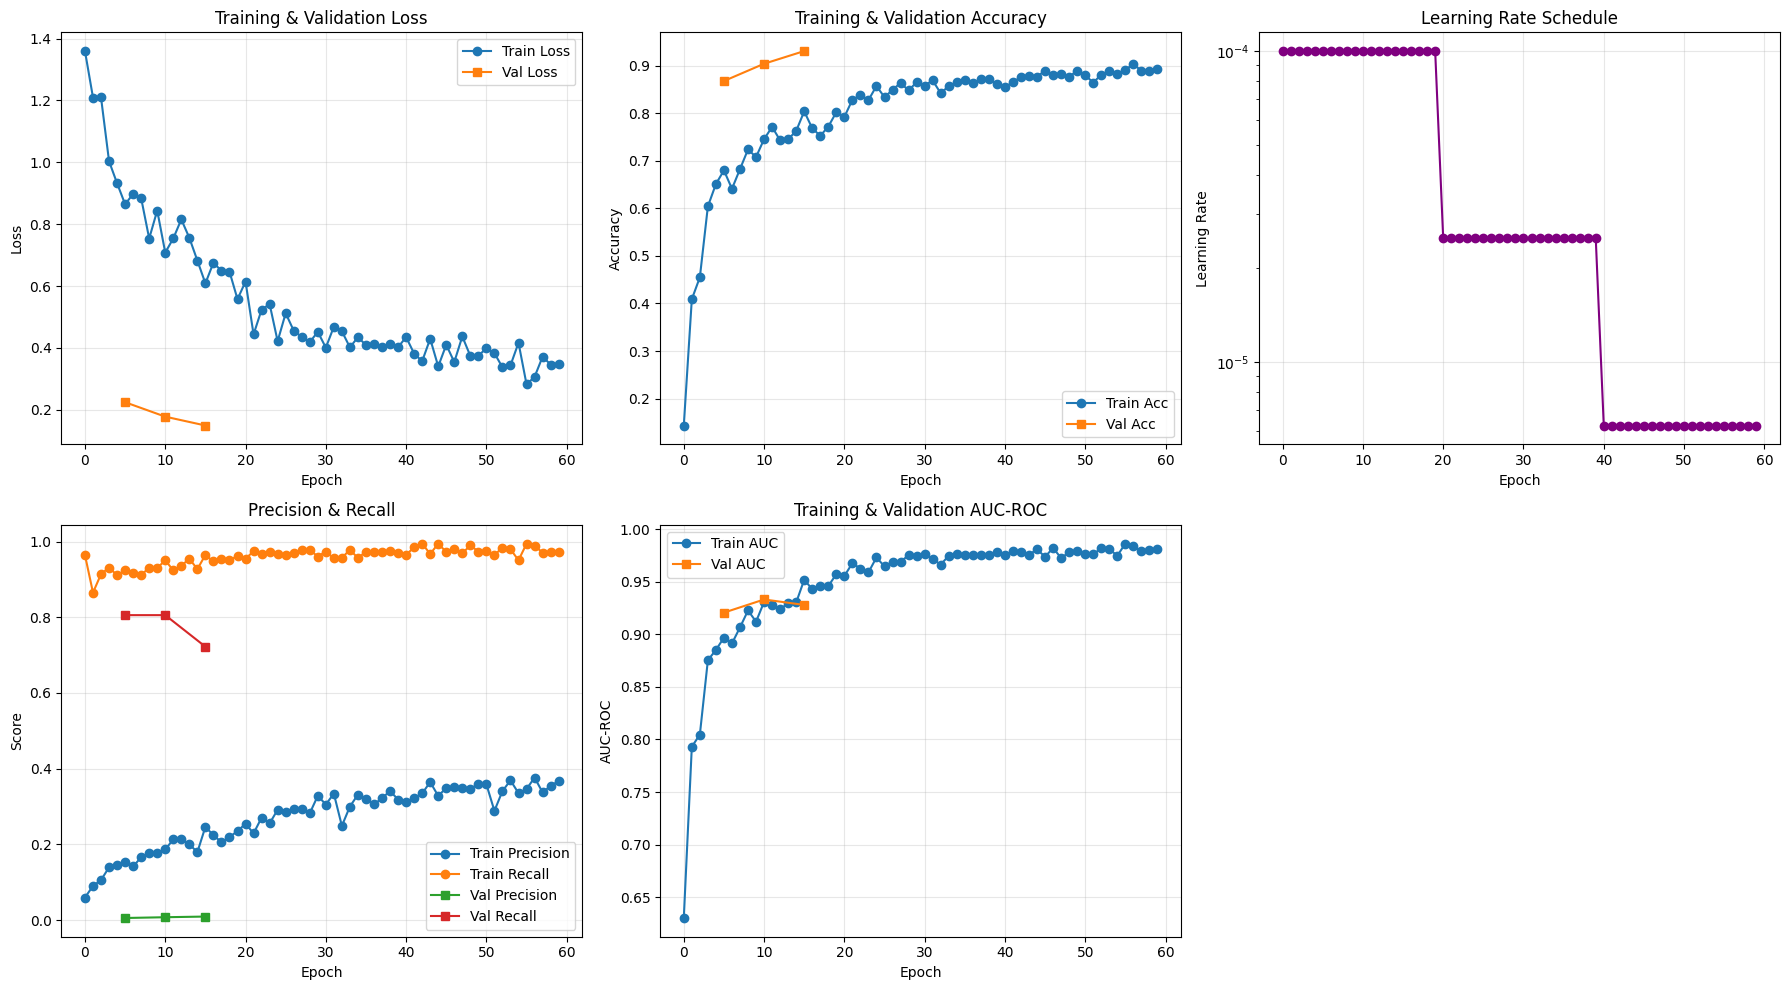

In [18]:
# =============================================================================
# TRAIN THE MODEL
# =============================================================================

# Set number of epochs
NUM_EPOCHS = 60

# KEY VARIABLE: Classification threshold
CLASSIFICATION_THRESHOLD = 0.35

print("Starting multimodal model training...")
print(f"Training for {NUM_EPOCHS} epochs")
print(f"Device: {device}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Loss function: BCEWithLogitsLoss (pos_weight={conservative_ratio})")
print(f"LR Scheduler: ReduceLROnPlateau (reduces when val accuracy plateaus)")
print(f"Classification threshold: {CLASSIFICATION_THRESHOLD}")

# Train the efficientnet multimodal model
history = train_multimodal_model(
    model=efficientnet_multimodal_model,
    train_loader=train_loader_multimodal,
    valid_loader=valid_loader_multimodal,
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor(conservative_ratio).to(device)),
    optimizer=optimizer,
    epochs=NUM_EPOCHS,
    classification_threshold=CLASSIFICATION_THRESHOLD,
    scheduler=lr_scheduler
)

print("\nTraining completed!")
print(f"📁 Best model saved at: best_multimodal_model.pth")

# Plot training history with learning rate
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss plot
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
if history['val_loss']:
    val_epochs = [i*5 for i in range(1, len(history['val_loss'])+1)]
    axes[0, 0].plot(val_epochs, history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy plot
axes[0, 1].plot(history['train_acc'], label='Train Acc', marker='o')
if history['val_acc']:
    axes[0, 1].plot(val_epochs, history['val_acc'], label='Val Acc', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training & Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 🆕 Learning Rate plot
axes[0, 2].plot(history['learning_rates'], marker='o', color='purple')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Learning Rate')
axes[0, 2].set_title('Learning Rate Schedule')
axes[0, 2].set_yscale('log')  # Log scale for better visualization
axes[0, 2].grid(True, alpha=0.3)

# Precision/Recall plot
axes[1, 0].plot(history['train_precision'], label='Train Precision', marker='o')
axes[1, 0].plot(history['train_recall'], label='Train Recall', marker='o')
if history['val_precision']:
    axes[1, 0].plot(val_epochs, history['val_precision'], label='Val Precision', marker='s')
    axes[1, 0].plot(val_epochs, history['val_recall'], label='Val Recall', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Precision & Recall')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# AUC plot
axes[1, 1].plot(history['train_auc'], label='Train AUC', marker='o')
if history['val_auc']:
    axes[1, 1].plot(val_epochs, history['val_auc'], label='Val AUC', marker='s')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC-ROC')
axes[1, 1].set_title('Training & Validation AUC-ROC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Hide the extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

🚀 Starting Comprehensive Model Evaluation...
🔍 Comprehensive Model Evaluation on Validation Set...
   Processed 0/10024 batches...
   Processed 0/10024 batches...
   Processed 100/10024 batches...
   Processed 100/10024 batches...
   Processed 200/10024 batches...
   Processed 200/10024 batches...
   Processed 300/10024 batches...
   Processed 300/10024 batches...
   Processed 400/10024 batches...
   Processed 400/10024 batches...
   Processed 500/10024 batches...
   Processed 500/10024 batches...
   Processed 600/10024 batches...
   Processed 600/10024 batches...
   Processed 700/10024 batches...
   Processed 700/10024 batches...
   Processed 800/10024 batches...
   Processed 800/10024 batches...
   Processed 900/10024 batches...
   Processed 900/10024 batches...
   Processed 1000/10024 batches...
   Processed 1000/10024 batches...
   Processed 1100/10024 batches...
   Processed 1100/10024 batches...
   Processed 1200/10024 batches...
   Processed 1200/10024 batches...
   Processed 13

C:\Users\alexs\AppData\Local\Temp\ipykernel_6068\10242930.py:260: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\alexs\AppData\Local\Temp\ipykernel_6068\10242930.py:260: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\alexs\AppData\Local\Temp\ipykernel_6068\10242930.py:260: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\alexs\AppData\Local\Temp\ipykernel_6068\10242930.py:260: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\alexs\AppData\Local\Temp\ipykernel_6068\10242930.py:260: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\alexs\AppData\Local\Temp\ipykernel_6068\10242930.py:260: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing

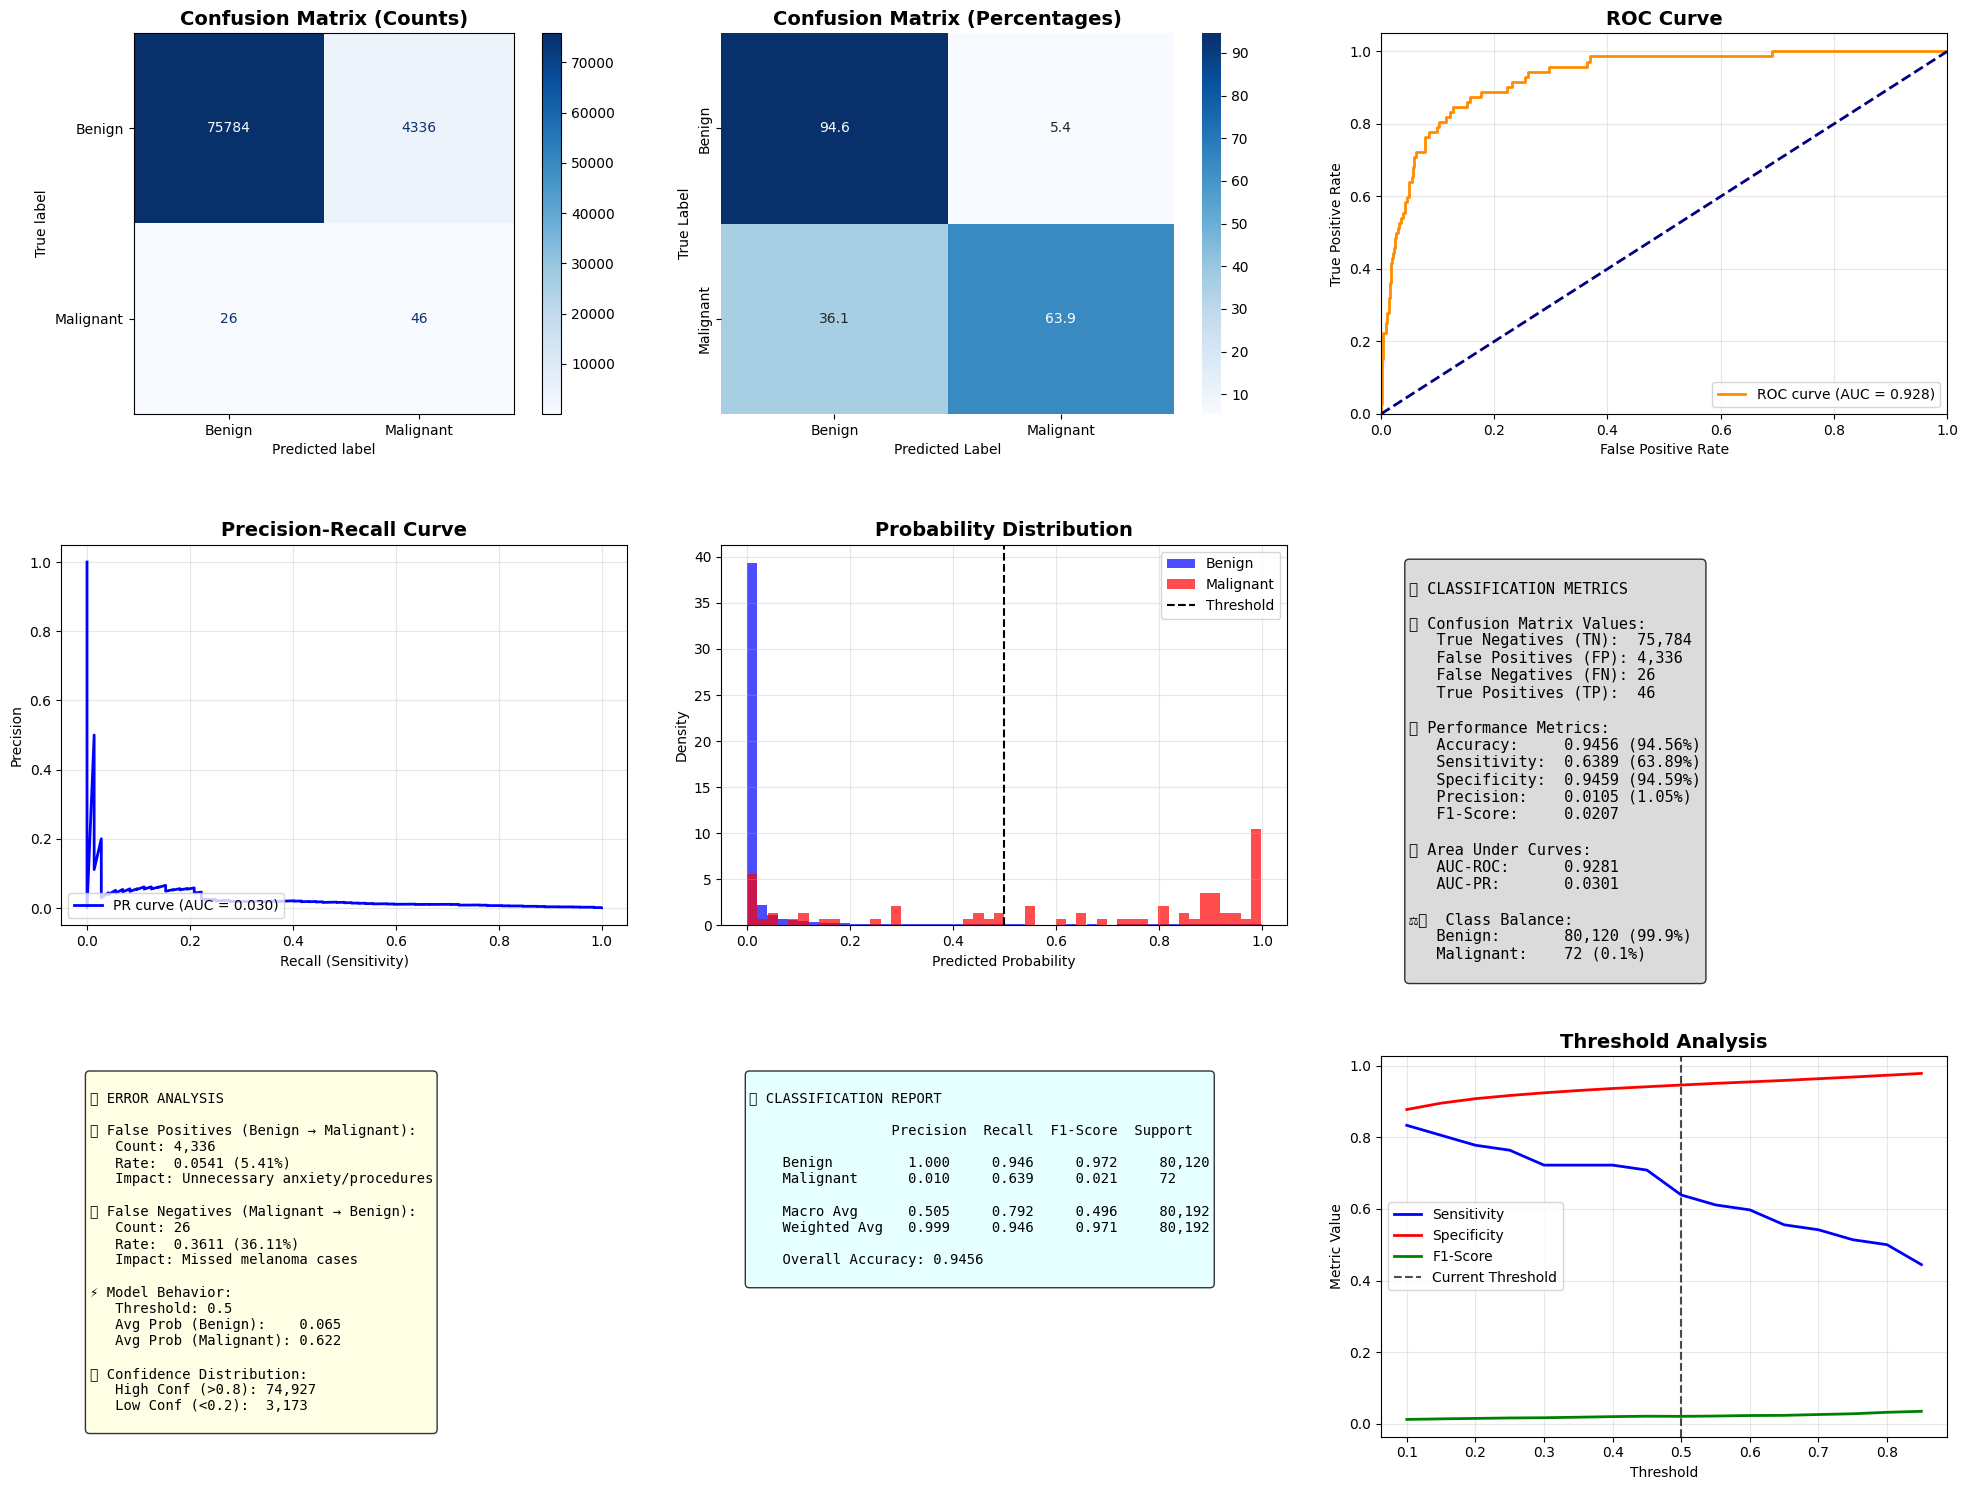


✅ Confusion Matrix Analysis Complete!
📊 Key Results:
   • Accuracy: 0.9456 (94.56%)
   • AUC-ROC: 0.9281
   • Sensitivity (Recall): 0.6389
   • Specificity: 0.9459
   • F1-Score: 0.0207
   • False Positive Rate: 0.0541
   • False Negative Rate: 0.3611


In [19]:
# =============================================================================
# COMPREHENSIVE CONFUSION MATRIX ANALYSIS
# =============================================================================

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model_comprehensive():
    """
    Comprehensive evaluation of the multimodal model on validation set
    """
    print("🔍 Comprehensive Model Evaluation on Validation Set...")
    
    efficientnet_multimodal_model.eval()
    all_predictions = []
    all_probabilities = []
    all_labels = []
    all_ids = []
    
    with torch.no_grad():
        for batch_idx, (images, metadata, labels, isic_ids) in enumerate(valid_loader_multimodal):
            # Move to device
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)
            
            # Forward pass
            logits = efficientnet_multimodal_model(images, metadata)
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities > 0.5).float()
            
            # Collect results
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_ids.extend(isic_ids)
            
            if batch_idx % 100 == 0:
                print(f"   Processed {batch_idx}/{len(valid_loader_multimodal)} batches...")
    
    # Convert to numpy arrays
    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)
    y_prob = np.array(all_probabilities)
    
    print(f"✅ Evaluation completed!")
    print(f"   Total samples: {len(y_true)}")
    print(f"   Benign samples: {np.sum(y_true == 0)} ({100*np.sum(y_true == 0)/len(y_true):.1f}%)")
    print(f"   Malignant samples: {np.sum(y_true == 1)} ({100*np.sum(y_true == 1)/len(y_true):.1f}%)")
    
    return y_true, y_pred, y_prob, all_ids

def create_comprehensive_confusion_matrix(y_true, y_pred, y_prob):
    """
    Create comprehensive confusion matrix with multiple visualizations
    """
    print("\n📊 Creating Comprehensive Confusion Matrix Analysis...")
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall/True Positive Rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    # Calculate AUC-ROC
    auc_roc = roc_auc_score(y_true, y_prob)
    
    # Calculate AUC-PR
    auc_pr = average_precision_score(y_true, y_prob)
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Confusion Matrix (normalized)
    ax1 = plt.subplot(3, 3, 1)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                       display_labels=['Benign', 'Malignant'])
    cm_display.plot(ax=ax1, cmap='Blues', values_format='d')
    ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    
    # 2. Confusion Matrix (percentages)
    ax2 = plt.subplot(3, 3, 2)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=['Benign', 'Malignant'], 
                yticklabels=['Benign', 'Malignant'], ax=ax2)
    ax2.set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')
    
    # 3. ROC Curve
    ax3 = plt.subplot(3, 3, 3)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax3.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {auc_roc:.3f})')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=14, fontweight='bold')
    ax3.legend(loc="lower right")
    ax3.grid(True, alpha=0.3)
    
    # 4. Precision-Recall Curve
    ax4 = plt.subplot(3, 3, 4)
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
    ax4.plot(recall_vals, precision_vals, color='blue', lw=2,
             label=f'PR curve (AUC = {auc_pr:.3f})')
    ax4.set_xlabel('Recall (Sensitivity)')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax4.legend(loc="lower left")
    ax4.grid(True, alpha=0.3)
    
    # 5. Probability Distribution
    ax5 = plt.subplot(3, 3, 5)
    benign_probs = y_prob[y_true == 0]
    malignant_probs = y_prob[y_true == 1]
    ax5.hist(benign_probs, bins=50, alpha=0.7, label='Benign', color='blue', density=True)
    ax5.hist(malignant_probs, bins=50, alpha=0.7, label='Malignant', color='red', density=True)
    ax5.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
    ax5.set_xlabel('Predicted Probability')
    ax5.set_ylabel('Density')
    ax5.set_title('Probability Distribution', fontsize=14, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Metrics Summary
    ax6 = plt.subplot(3, 3, 6)
    ax6.axis('off')
    metrics_text = f"""
🎯 CLASSIFICATION METRICS

📊 Confusion Matrix Values:
   True Negatives (TN):  {tn:,}
   False Positives (FP): {fp:,}
   False Negatives (FN): {fn:,}
   True Positives (TP):  {tp:,}

📈 Performance Metrics:
   Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)
   Sensitivity:  {sensitivity:.4f} ({sensitivity*100:.2f}%)
   Specificity:  {specificity:.4f} ({specificity*100:.2f}%)
   Precision:    {precision:.4f} ({precision*100:.2f}%)
   F1-Score:     {f1_score:.4f}

🎯 Area Under Curves:
   AUC-ROC:      {auc_roc:.4f}
   AUC-PR:       {auc_pr:.4f}

⚖️  Class Balance:
   Benign:       {np.sum(y_true == 0):,} ({100*np.sum(y_true == 0)/len(y_true):.1f}%)
   Malignant:    {np.sum(y_true == 1):,} ({100*np.sum(y_true == 1)/len(y_true):.1f}%)
    """
    ax6.text(0.05, 0.95, metrics_text, transform=ax6.transAxes, 
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # 7. Error Analysis
    ax7 = plt.subplot(3, 3, 7)
    ax7.axis('off')
    
    # False Positives and False Negatives analysis
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    error_text = f"""
🚨 ERROR ANALYSIS

❌ False Positives (Benign → Malignant):
   Count: {fp:,}
   Rate:  {fp_rate:.4f} ({fp_rate*100:.2f}%)
   Impact: Unnecessary anxiety/procedures

❌ False Negatives (Malignant → Benign):
   Count: {fn:,}
   Rate:  {fn_rate:.4f} ({fn_rate*100:.2f}%)
   Impact: Missed melanoma cases

⚡ Model Behavior:
   Threshold: 0.5
   Avg Prob (Benign):    {np.mean(benign_probs):.3f}
   Avg Prob (Malignant): {np.mean(malignant_probs):.3f}
   
📊 Confidence Distribution:
   High Conf (>0.8): {np.sum(np.abs(y_prob - 0.5) > 0.3):,}
   Low Conf (<0.2):  {np.sum(np.abs(y_prob - 0.5) < 0.2):,}
    """
    ax7.text(0.05, 0.95, error_text, transform=ax7.transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    # 8. Classification Report
    ax8 = plt.subplot(3, 3, 8)
    ax8.axis('off')
    
    # Get classification report
    report = classification_report(y_true, y_pred, 
                                 target_names=['Benign', 'Malignant'], 
                                 output_dict=True)
    
    report_text = f"""
📋 CLASSIFICATION REPORT

                 Precision  Recall  F1-Score  Support
    
    Benign         {report['Benign']['precision']:.3f}     {report['Benign']['recall']:.3f}     {report['Benign']['f1-score']:.3f}     {int(report['Benign']['support']):,}
    Malignant      {report['Malignant']['precision']:.3f}     {report['Malignant']['recall']:.3f}     {report['Malignant']['f1-score']:.3f}     {int(report['Malignant']['support']):,}
    
    Macro Avg      {report['macro avg']['precision']:.3f}     {report['macro avg']['recall']:.3f}     {report['macro avg']['f1-score']:.3f}     {int(report['macro avg']['support']):,}
    Weighted Avg   {report['weighted avg']['precision']:.3f}     {report['weighted avg']['recall']:.3f}     {report['weighted avg']['f1-score']:.3f}     {int(report['weighted avg']['support']):,}
    
    Overall Accuracy: {accuracy:.4f}
    """
    
    ax8.text(0.05, 0.95, report_text, transform=ax8.transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
    
    # 9. Threshold Analysis
    ax9 = plt.subplot(3, 3, 9)
    thresholds = np.arange(0.1, 0.9, 0.05)
    sensitivities = []
    specificities = []
    f1_scores = []
    
    for threshold in thresholds:
        y_pred_thresh = (y_prob > threshold).astype(int)
        cm_thresh = confusion_matrix(y_true, y_pred_thresh)
        tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()
        
        sens_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        spec_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        f1_t = 2 * (prec_t * sens_t) / (prec_t + sens_t) if (prec_t + sens_t) > 0 else 0
        
        sensitivities.append(sens_t)
        specificities.append(spec_t)
        f1_scores.append(f1_t)
    
    ax9.plot(thresholds, sensitivities, 'b-', label='Sensitivity', linewidth=2)
    ax9.plot(thresholds, specificities, 'r-', label='Specificity', linewidth=2)
    ax9.plot(thresholds, f1_scores, 'g-', label='F1-Score', linewidth=2)
    ax9.axvline(x=0.5, color='black', linestyle='--', alpha=0.7, label='Current Threshold')
    ax9.set_xlabel('Threshold')
    ax9.set_ylabel('Metric Value')
    ax9.set_title('Threshold Analysis', fontsize=14, fontweight='bold')
    ax9.legend()
    ax9.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n✅ Confusion Matrix Analysis Complete!")
    print(f"📊 Key Results:")
    print(f"   • Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   • AUC-ROC: {auc_roc:.4f}")
    print(f"   • Sensitivity (Recall): {sensitivity:.4f}")
    print(f"   • Specificity: {specificity:.4f}")
    print(f"   • F1-Score: {f1_score:.4f}")
    print(f"   • False Positive Rate: {fp_rate:.4f}")
    print(f"   • False Negative Rate: {fn_rate:.4f}")
    
    return {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1_score': f1_score,
        'auc_roc': auc_roc,
        'auc_pr': auc_pr,
        'false_positive_rate': fp_rate,
        'false_negative_rate': fn_rate
    }

# Run the comprehensive evaluation
print("🚀 Starting Comprehensive Model Evaluation...")
y_true, y_pred, y_prob, sample_ids = evaluate_model_comprehensive()
metrics = create_comprehensive_confusion_matrix(y_true, y_pred, y_prob)

🔮 Generating submission file...
✅ Model file found at: b4_epoch60.pth
📂 Loading best model from b4_epoch60.pth...
📂 Loading best model from b4_epoch60.pth...
🔮 Generating predictions on test set...
🔮 Generating predictions on test set...


Inference:   0%|          | 0/13 [00:00<?, ?it/s]

✅ Submission saved: multimodal_submission.csv
📊 Predictions generated for 100 test samples

📈 Prediction Statistics:
   Mean: 0.3644
   Std: 0.4136
   Min: 0.0000
   Max: 0.9989
   Predictions > 0.5: 35 (35.0%)
📁 Analyzing submission file: multimodal_submission.csv
✅ Submission file loaded successfully!
📊 Submission shape: (100, 2)
📋 Columns: ['isic_id', 'target']
All required columns present

📈 Prediction Statistics:
   Total predictions: 100
   Mean probability: 0.364353
   Std probability: 0.413608
   Min probability: 0.000000
   Max probability: 0.998865
   Median probability: 0.103981

📊 Prediction Distribution:
   Predictions > 0.1: 50 (50.00%)
   Predictions > 0.3: 43 (43.00%)
   Predictions > 0.5: 35 (35.00%)
   Predictions > 0.7: 31 (31.00%)
   Predictions > 0.9: 23 (23.00%)


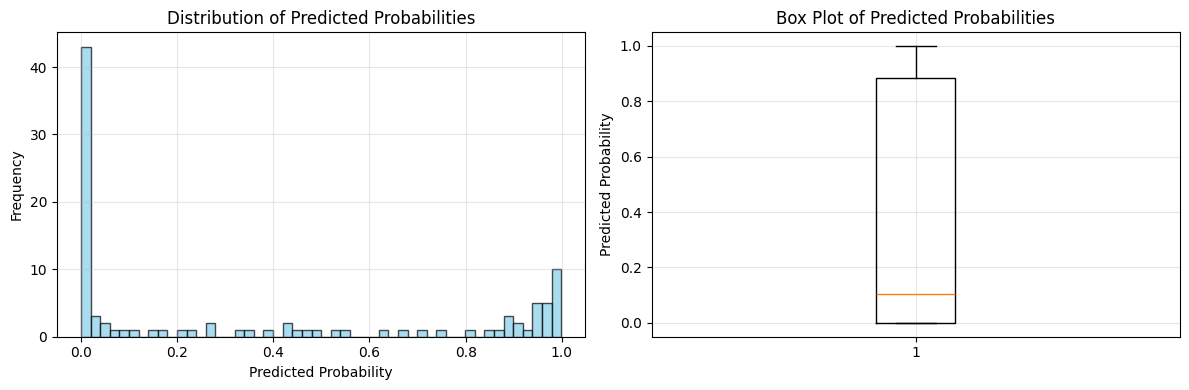


First 10 rows of submission:
     isic_id   target
ISIC_0082829 0.433588
ISIC_0114227 0.036904
ISIC_0157465 0.000020
ISIC_0197356 0.011932
ISIC_0275647 0.000022
ISIC_0332355 0.003587
ISIC_0528190 0.975152
ISIC_0576478 0.000005
ISIC_0719839 0.944740
ISIC_0968965 0.984422

✅ No duplicate isic_id entries found

✅ Ready to submit to Kaggle!


In [18]:
# =============================================================================
# GENERATE SUBMISSION
# =============================================================================

print("🔮 Generating submission file...")

# Use the correct model path from training
MODEL_PATH = "b4_epoch60.pth"  # This is where training saves it

# Check if the model file exists
import os
if not os.path.exists(MODEL_PATH):
    print(f"❌ Model file not found at: {MODEL_PATH}")
    print(f"📁 Looking for available model files...")
    # List all .pth files in current directory
    pth_files = [f for f in os.listdir('.') if f.endswith('.pth')]
    print(f"   Found: {pth_files}")
else:
    print(f"✅ Model file found at: {MODEL_PATH}")

# Load the model's state dictionary
efficientnet_multimodal_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

# Generate submission (don't pass model_path again since we already loaded it)
submission_df = generate_multimodal_submission(
    model=efficientnet_multimodal_model,
    test_loader=test_loader_multimodal,
    model_path=MODEL_PATH  # Pass the correct path
)

# Analyze the submission file
submission_analysis = analyze_submission_file("multimodal_submission.csv")


print("\n✅ Ready to submit to Kaggle!")

In [ ]:
# =============================================================================
# Interpretability with GradCAM
# =============================================================================
print("\n🔬 Starting GradCAM analysis on validation set...")
analyze_gradcam_examples(num_examples=2)

## only image model

In [9]:
class EfficientNetImageOnly(nn.Module):
    """Image-only model using EfficientNet backbone (no metadata)"""
    
    def __init__(self, dropout_rate=0.3):
        super(EfficientNetImageOnly, self).__init__()
        
        # EfficientNet backbone
        from torchvision.models import efficientnet_b4
        self.image_backbone = efficientnet_b4(pretrained=True)
        
        # Remove classifier to get features
        self.image_features = nn.Sequential(*list(self.image_backbone.children())[:-1])
        
        # EfficientNet-B4 outputs 1792 features
        image_feature_dim = 1792
        
        # Classification head (image only)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(image_feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 1)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in [self.classifier]:
            for layer in module.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight)
                    nn.init.constant_(layer.bias, 0)
    
    def forward(self, image):
        # Image features
        image_features = self.image_features(image)
        image_features = F.adaptive_avg_pool2d(image_features, (1, 1))
        image_features = image_features.view(image_features.size(0), -1)
        
        # Classification
        logits = self.classifier(image_features)
        return logits.view(-1)

print("✅ EfficientNetImageOnly class created!")

✅ EfficientNetImageOnly class created!


In [15]:
SAMPLES_PER_EPOCH = 2500

# Create image-only dataset (no metadata)
class ImageOnlyDataset(Dataset):
    """Dataset for image-only training (no metadata)"""
    
    def __init__(self, df, hdf5_path, image_transform=None, is_labelled=True):
        self.df = df.reset_index(drop=True)
        self.hdf5_path = hdf5_path
        self.image_transform = image_transform
        self.is_labelled = is_labelled
        
        # Keep HDF5 file open for performance
        self.hdf5_file = h5py.File(self.hdf5_path, 'r')
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        isic_id = row["isic_id"]
        
        # Load and transform image
        image_rgb = self._load_image_from_hdf5(isic_id)
        
        if self.image_transform is not None:
            import torchvision.transforms.functional as F_v
            image_pil = F_v.to_pil_image(image_rgb)
            image = self.image_transform(image_pil)
        else:
            image = torch.from_numpy(image_rgb).permute(2, 0, 1).float()
        
        if self.is_labelled:
            label = torch.tensor(row["target"]).float()
            return image, label, isic_id
        else:
            return image, isic_id
    
    def _load_image_from_hdf5(self, isic_id):
        """Load image from already-open HDF5 file"""
        encoded_bytes = self.hdf5_file[isic_id][()]
        image_bgr = cv2.imdecode(encoded_bytes, cv2.IMREAD_COLOR)
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image_rgb
    
    def __del__(self):
        """Clean up: close HDF5 file"""
        if hasattr(self, 'hdf5_file') and self.hdf5_file:
            self.hdf5_file.close()


# Create image-only datasets
print("Creating image-only datasets...")

train_image_dataset = ImageOnlyDataset(
    df=train_df_sub,
    hdf5_path=TRAIN_HDF5,
    image_transform=train_transforms,
    is_labelled=True
)

valid_image_dataset = ImageOnlyDataset(
    df=valid_df_sub,
    hdf5_path=TRAIN_HDF5,
    image_transform=val_transforms,
    is_labelled=True
)

test_image_dataset = ImageOnlyDataset(
    df=test_df,
    hdf5_path=TEST_HDF5,
    image_transform=val_transforms,
    is_labelled=False
)

# Create weighted sampler for image-only training
image_train_targets = train_image_dataset.df['target'].values
image_sample_weights = calculate_sample_weights(image_train_targets, class_weights)

image_weighted_sampler = WeightedRandomSampler(
    weights=image_sample_weights,
    num_samples=SAMPLES_PER_EPOCH,  # Same as multimodal
    replacement=True
)

# Create data loaders for image-only training
train_image_loader = DataLoader(
    train_image_dataset,
    batch_size=BATCH_SIZE,
    sampler=image_weighted_sampler,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

val_image_loader = DataLoader(
    valid_image_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

test_image_loader = DataLoader(
    test_image_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

print("✅ Image-only datasets and data loaders created!")
print(f"   Training batches per epoch: {len(train_image_loader)}")
print(f"   Validation batches: {len(val_image_loader)}")
print(f"   Test batches: {len(test_image_loader)}")

Creating image-only datasets...
✅ Image-only datasets and data loaders created!
   Training batches per epoch: 313
   Validation batches: 10024
   Test batches: 13


In [16]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
# Initialize image-only model
image_only_model = EfficientNetImageOnly(dropout_rate=0.3).to(device)

# Freeze backbone initially for gradual unfreezing
for param in image_only_model.image_backbone.parameters():
    param.requires_grad = False

# Setup optimizer and criterion
optimizer_image = torch.optim.AdamW(image_only_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_image = torch.optim.lr_scheduler.StepLR(
    optimizer_image, step_size=10, gamma=0.8
)
criterion_image = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(25.0).to(device))

print("✅ Image-only model initialized!")
print(f"   Total parameters: {sum(p.numel() for p in image_only_model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in image_only_model.parameters() if p.requires_grad):,}")
print(f"   Backbone frozen initially (will unfreeze progressively every 10 epochs)")

✅ Image-only model initialized!
   Total parameters: 20,391,217
   Trainable parameters: 1,049,601
   Backbone frozen initially (will unfreeze progressively every 10 epochs)


In [20]:
# Train image-only model
EPOCHS_IMAGE = 90
best_auc_image = 0.0
patience_counter_image = 0
PATIENCE_IMAGE = 5

print("Starting image-only model training...")

for epoch in range(EPOCHS_IMAGE):
    # ===== TRAINING =====
    image_only_model.train()
    train_loss = 0
    train_labels_all = []
    train_probs_all = []
    
    for batch_data in tqdm(train_image_loader, desc=f"Epoch {epoch+1}/{EPOCHS_IMAGE}"):
        images, labels, _ = batch_data
        
        images = images.to(device)
        labels = labels.float().to(device)
        
        logits = image_only_model(images)
        loss = criterion_image(logits, labels)
        
        optimizer_image.zero_grad()
        loss.backward()
        optimizer_image.step()
        
        train_loss += loss.item()
        
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            train_labels_all.extend(labels.cpu().numpy())
            train_probs_all.extend(probs.cpu().numpy())
    
    avg_train_loss = train_loss / len(train_image_loader)
    train_labels_all = np.array(train_labels_all)
    train_probs_all = np.array(train_probs_all)
    train_auc = roc_auc_score(train_labels_all, train_probs_all) if len(np.unique(train_labels_all)) > 1 else 0.0
    
    # Update scheduler every epoch
    scheduler_image.step()
    current_lr = optimizer_image.param_groups[0]['lr']
    
    # ===== PROGRESSIVE UNFREEZING (every 10 epochs) =====
    if (epoch + 1) % 15 == 0:
        # Get all backbone layers (in reverse order to unfreeze from end)
        backbone_layers = list(image_only_model.image_backbone.children())
        layer_idx = ((epoch + 1) // 10) - 1  # 0-indexed layer to unfreeze
        
        if layer_idx < len(backbone_layers):
            # Unfreeze the layer from the end
            target_layer = backbone_layers[-(layer_idx + 1)]
            for param in target_layer.parameters():
                param.requires_grad = True
            
            # Update optimizer to include newly unfrozen parameters
            optimizer_image = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, image_only_model.parameters()),
                lr=current_lr,
                weight_decay=1e-4
            )
            scheduler_image = torch.optim.lr_scheduler.StepLR(
                optimizer_image, step_size=10, gamma=0.8
            )
            
            trainable_params = sum(p.numel() for p in image_only_model.parameters() if p.requires_grad)
            print(f"  🔓 Unfroze backbone layer {layer_idx + 1} | Trainable params: {trainable_params:,}")
    
    print(f"\nEpoch {epoch+1}/{EPOCHS_IMAGE} - Train Loss: {avg_train_loss:.4f} | Train AUC: {train_auc:.4f} | LR: {current_lr:.6f}")
    
    # ===== VALIDATION (every 20 epochs) =====
    if (epoch + 1) % 30 == 0:
        image_only_model.eval()
        val_loss = 0
        val_labels_all = []
        val_probs_all = []
        
        with torch.no_grad():
            for batch_data in tqdm(val_image_loader, desc=f"Validation {epoch+1}/{EPOCHS_IMAGE}", leave=False):
                images, labels, _ = batch_data
                
                images = images.to(device)
                labels = labels.float().to(device)
                
                logits = image_only_model(images)
                loss = criterion_image(logits, labels)
                val_loss += loss.item()
                
                probs = torch.sigmoid(logits)
                val_labels_all.extend(labels.cpu().numpy())
                val_probs_all.extend(probs.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_image_loader)
        val_labels_all = np.array(val_labels_all)
        val_probs_all = np.array(val_probs_all)
        val_auc = roc_auc_score(val_labels_all, val_probs_all)
        val_acc = np.mean((val_probs_all > 0.35) == val_labels_all)
        
        print(f"  📊 Validation Results (threshold=0.35):")
        print(f"     Val Loss:   {avg_val_loss:.4f} | Val AUC: {val_auc:.4f} | Val Acc: {val_acc:.4f}")
        
        # Save best model
        if val_auc > best_auc_image:
            best_auc_image = val_auc
            patience_counter_image = 0
            torch.save(image_only_model.state_dict(), "efficientnet_image_only.pth")
            print(f"     ✅ New best model saved! (Val AUC: {best_auc_image:.4f})")
        else:
            patience_counter_image += 1
            print(f"     No improvement ({patience_counter_image}/{PATIENCE_IMAGE})")
            
            if patience_counter_image >= PATIENCE_IMAGE:
                print(f"\n⚠️ Early stopping triggered after {epoch+1} epochs")
                break

print("\n✅ Image-only model training completed!")
print(f"Best validation AUC: {best_auc_image:.4f}")

Starting image-only model training...


Epoch 1/90:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 1/90 - Train Loss: 0.9216 | Train AUC: 0.5190 | LR: 0.000100


Epoch 2/90:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 2/90 - Train Loss: 0.9109 | Train AUC: 0.5778 | LR: 0.000100


...


Epoch 89/90 - Train Loss: 0.4502 | Train AUC: 0.9248 | LR: 0.000021


Epoch 90/90:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 90/90 - Train Loss: 0.3121 | Train AUC: 0.9494 | LR: 0.000017


Validation 90/90:   0%|          | 0/10024 [00:00<?, ?it/s]

  📊 Validation Results (threshold=0.35):
     Val Loss:   0.1782 | Val AUC: 0.8944 | Val Acc: 0.9015
     ✅ New best model saved! (Val AUC: 0.8944)

✅ Image-only model training completed!
Best validation AUC: 0.8944
     ✅ New best model saved! (Val AUC: 0.8944)

✅ Image-only model training completed!
Best validation AUC: 0.8944


In [1]:
# Generate submission with image-only model
print("🔮 Generating submission with image-only model...")

# Load best model
image_only_model.load_state_dict(torch.load("efficientnet_image_only.pth", map_location=device))
image_only_model.eval()

predictions = []

with torch.no_grad():
    for batch_data in tqdm(test_image_loader, desc="Inference"):
        images, isic_ids = batch_data
        
        images = images.to(device)
        
        logits = image_only_model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        for isic_id, prob in zip(isic_ids, probs):
            predictions.append({"isic_id": isic_id, "target": float(prob)})

# Create submission DataFrame
image_only_submission_df = pd.DataFrame(predictions)
image_only_submission_df = image_only_submission_df.sort_values(by="isic_id").reset_index(drop=True)

submission_file = "efficientnet_image_only_submission.csv"
image_only_submission_df.to_csv(submission_file, index=False)

print(f"\n✅ Submission saved: {submission_file}")
print(f"📊 Predictions generated for {len(image_only_submission_df):,} test samples")
print(f"\n📈 Prediction Statistics:")
print(f"   Mean: {image_only_submission_df['target'].mean():.4f}")
print(f"   Std: {image_only_submission_df['target'].std():.4f}")
print(f"   Min: {image_only_submission_df['target'].min():.4f}")
print(f"   Max: {image_only_submission_df['target'].max():.4f}")
print(f"   Predictions > 0.5: {(image_only_submission_df['target'] > 0.5).sum():,} ({(image_only_submission_df['target'] > 0.5).mean()*100:.1f}%)")

🔮 Generating submission with image-only model...


NameError: name 'image_only_model' is not defined

### Generate Predictions for Training Data

In [ ]:
# Generate predictions for the entire training dataset
print("🔮 Generating predictions for training data...")

# Load best model
image_only_model.load_state_dict(torch.load("efficientnet_image_only.pth", map_location=device))
image_only_model.eval()

# Create dataset for entire training data (without augmentation)
train_full_dataset = ImageOnlyDataset(
    df=train_df,  # Use the full train_df, not train_df_sub
    hdf5_path=TRAIN_HDF5,
    image_transform=val_transforms,  # Use validation transforms (no augmentation)
    is_labelled=True
)

# Create dataloader (no sampling, process all data)
train_full_loader = DataLoader(
    train_full_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

# Generate predictions
predictions_list = []

with torch.no_grad():
    for batch_data in tqdm(train_full_loader, desc="Generating predictions"):
        images, labels, isic_ids = batch_data
        
        images = images.to(device)
        
        logits = image_only_model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        for isic_id, prob in zip(isic_ids, probs):
            predictions_list.append({"isic_id": isic_id, "prediction": float(prob)})

# Create predictions DataFrame
predictions_df = pd.DataFrame(predictions_list)

# Merge with original train metadata
train_with_predictions = train_df.merge(predictions_df, on='isic_id', how='left')

# Save to CSV
output_file = "train_metadata_with_predictions.csv"
train_with_predictions.to_csv(output_file, index=False)

print(f"\n✅ Training predictions saved: {output_file}")
print(f"📊 Predictions generated for {len(train_with_predictions):,} training samples")
print(f"\n📈 Prediction Statistics:")
print(f"   Mean: {train_with_predictions['prediction'].mean():.4f}")
print(f"   Std: {train_with_predictions['prediction'].std():.4f}")
print(f"   Min: {train_with_predictions['prediction'].min():.4f}")
print(f"   Max: {train_with_predictions['prediction'].max():.4f}")
print(f"   Predictions > 0.35: {(train_with_predictions['prediction'] > 0.35).sum():,} ({(train_with_predictions['prediction'] > 0.35).mean()*100:.1f}%)")

# Display first few rows
print(f"\n📋 Sample of predictions:")
print(train_with_predictions[['isic_id', 'target', 'prediction']].head(10))